In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s


In [71]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [1,2,3,4]
b_coeffs = ["2-s**3",5,6,7]
#get bpmeth opbject
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
#expansion.plot_components()
# plt.xlabel('s')
# plt.xlim((0,1))

/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:96: UserWarning: The laplacian could not be evaluated
  warnings.warn("The laplacian could not be evaluated")


Scalar potential phi(x,y,s): x**4/6 + x**3/2 + x**2 + x + y**4/6 - y**3*(-36*s + 42*x + 36)/36 - y**2*(48*x**2 + 72*x + 48)/48 + y*(-6*s**3 + 7*x**3 + 18*x**2 + 30*x + 12)/6
Scalar potential phi at (0.4,0.2,0.5): 1.4043333333333334


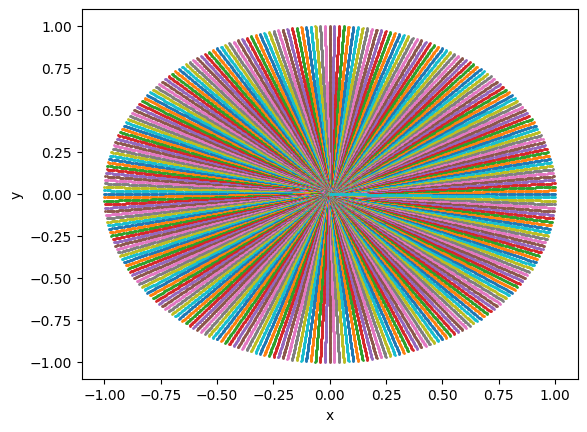

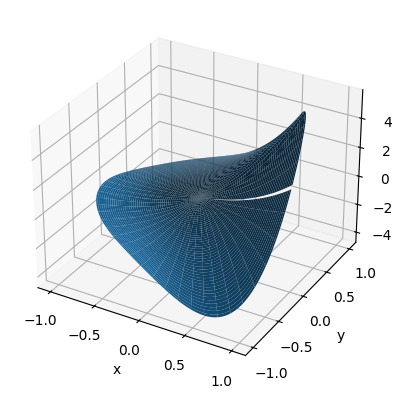

In [72]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define r, theta, s axes to convert the symbolic expression of phi into a numerical array
# npoints=201
# xa= np.linspace(-1,1,npoints) 
# ya=np.linspace(-1,1,npoints)
rmin, rmax, nr = 0.001, 1.001, 200
ntheta = 300
rr = np.linspace(rmin, rmax, nr)
tt = np.arange(ntheta)/ntheta*2*np.pi
ss = np.linspace(-1,1, 40)

rarr, tarr, sarr = np.meshgrid(rr, tt, ss, indexing='ij')
xarr = rarr*np.cos(tarr)
yarr = rarr*np.sin(tarr)
#make a 3d plot of phi as a function of x and y for a fixed s
plt.plot(xarr[:,:,0], yarr[:,:,0], 'o', markersize=1)
plt.xlabel("x")
plt.ylabel("y")
P = phi_func(xarr[:,:,0], yarr[:,:,0], 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xarr[:,:,0], yarr[:,:,0],P)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [73]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)#with lambdify=False
# Evaluate on grid
#X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(xarr, yarr, sarr)
By_ana = By_func(xarr, yarr, sarr)
Bs_ana = Bs_func(xarr, yarr, sarr)
print(By_ana.shape)

(200, 300, 40)


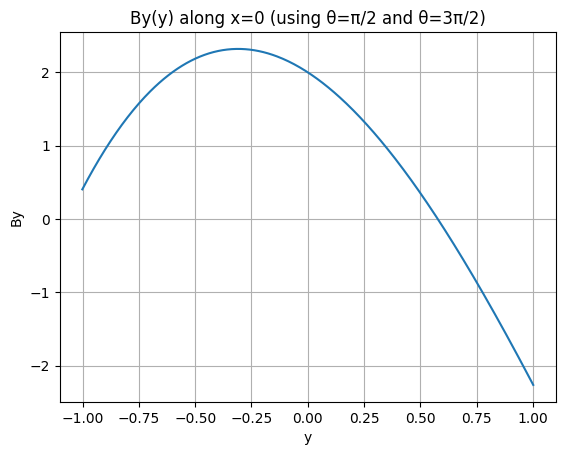

In [74]:
#Plot By as a function of y for x=0
islice = 20   # choose an s index
# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
By_pos = By_ana[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
By_neg = By_ana[:, itheta_neg, islice]

# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
By_all = np.concatenate([By_neg, By_pos])

order = np.argsort(y_all)
y_all = y_all[order]
By_all = By_all[order]

plt.plot(y_all, By_all)
plt.xlabel("y")
plt.ylabel("By")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")
plt.grid(True)


In [75]:
Ax, Ay, As = expansion.get_A(lambdify=True)
#print("Ax:", Ax, "Ay:", Ay, "As:", As)#with lambdify False
Ax_ana = Ax(xarr, yarr, sarr)
Ay_ana = Ay(xarr, yarr, sarr)
As_ana = As(xarr, yarr, sarr)


In [76]:
#then take the curl of A from finite differences and compare with the original B field
def curl_cylindrical_from_cartesian(Ax, Ay, Az, rarr, tarr, sarr):
    """
    Compute curl(A) on a cylindrical grid (r, theta, s),
    where A is given in Cartesian components (Ax, Ay, Az).
    """

    # ---------------------------------------------------------
    # 1. Extract axes and spacings
    # ---------------------------------------------------------
    r_axis     = rarr[:,0,0]
    theta_axis = tarr[0,:,0]
    s_axis     = sarr[0,0,:]

    dr     = r_axis[1]     - r_axis[0]
    dtheta = theta_axis[1] - theta_axis[0]
    ds     = s_axis[1]     - s_axis[0]

    # ---------------------------------------------------------
    # 2. Convert A from Cartesian → cylindrical components
    # ---------------------------------------------------------
    cos_t = np.cos(tarr)
    sin_t = np.sin(tarr)

    Ar     =  Ax*cos_t + Ay*sin_t
    Atheta = -Ax*sin_t + Ay*cos_t
    Az_cyl =  Az

    # ---------------------------------------------------------
    # 3. Compute partial derivatives
    # ---------------------------------------------------------
    dAr_dtheta     = np.gradient(Ar,     dtheta, axis=1)
    dAtheta_dtheta = np.gradient(Atheta, dtheta, axis=1)
    dAz_dtheta     = np.gradient(Az_cyl, dtheta, axis=1)

    dAr_dr     = np.gradient(Ar,     dr, axis=0)
    dAtheta_dr = np.gradient(Atheta, dr, axis=0)
    dAz_dr     = np.gradient(Az_cyl, dr, axis=0)

    dAr_dz     = np.gradient(Ar,     ds, axis=2)
    dAtheta_dz = np.gradient(Atheta, ds, axis=2)
    dAz_ds     = np.gradient(Az_cyl, ds, axis=2)

    # ---------------------------------------------------------
    # 4. Curl in cylindrical coordinates
    # ---------------------------------------------------------
    r = rarr

    curl_r = (1/r) * dAz_dtheta - dAtheta_dz
    curl_theta = dAr_dz - dAz_dr

    rAtheta = r * Atheta
    d_rAtheta_dr = np.gradient(rAtheta, dr, axis=0)

    curl_z = (1/r) * d_rAtheta_dr - (1/r) * dAr_dtheta

    # ---------------------------------------------------------
    # 5. Convert curl back to Cartesian components
    # ---------------------------------------------------------
    curl_x = curl_r*cos_t - curl_theta*sin_t
    curl_y = curl_r*sin_t + curl_theta*cos_t
    curl_s = curl_z

    return curl_x, curl_y, curl_s

curl_x, curl_y, curl_s = curl_cylindrical_from_cartesian(Ax_ana, Ay_ana, As_ana, rarr, tarr, sarr)
print(curl_x.shape, Bx_ana.shape)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_x - Bx_ana)))
print("Max relative difference in By:", np.max(np.abs(curl_y - By_ana))/np.max(np.abs(By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_s - Bs_ana)))


(200, 300, 40) (200, 300, 40)
Max difference in Bx: 0.2892809670190726
Max relative difference in By: 0.006196738586474769
Max difference in Bs: 0.06049127045911322


(200, 300, 40)
30


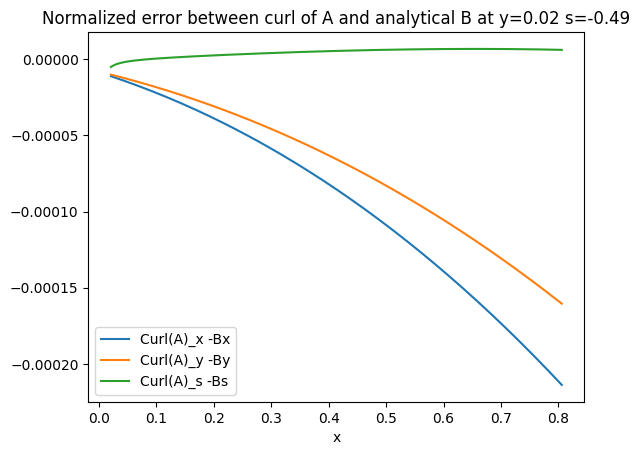

In [77]:
npoints=len(xarr)
print(xarr.shape)
truncatedxarr=xarr[5:npoints-1,30,10]#to avoid boundary effects from finite differences
#truncateds=sa[5:npoints-5]#to avoid boundary effects from finite differences
#position=(45, 54,slice(5,npoints-5))#x=0, y=0, all s
position=(slice(5,npoints-1), 30, 10)#all x, y=fixed, s=fixed
print(position[1])
Bmaxx=np.max([np.max(Bx_ana),np.max(By_ana),np.max(Bs_ana)])
plt.plot(truncatedxarr, (curl_x[position]-Bx_ana[position])/Bmaxx, label='Curl(A)_x -Bx')
plt.plot(truncatedxarr, (curl_y[position]-By_ana[position])/Bmaxx, label='Curl(A)_y -By')
plt.plot(truncatedxarr, (curl_s[position]-Bs_ana[position])/Bmaxx, label='Curl(A)_s -Bs')
#plt.ylim((np.min((curl_y[position]-By_ana[position])/By_ana[position]), np.max((curl_y[position]-By_ana[position])/By_ana[position])))
plt.legend()
plt.title('Normalized error between curl of A and analytical B at y='+str(np.round(yarr[position][1],2)) +" s="+str(np.round(sarr[position][2],2)))
plt.xlabel('x')
plt.show()


Text(0.5, 0, 'x')

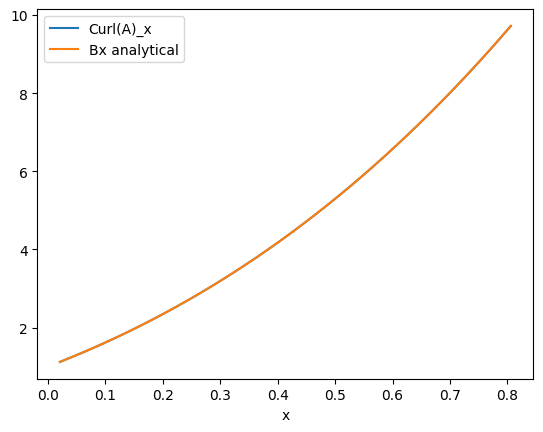

In [78]:
plt.plot(truncatedxarr, curl_x[position], label='Curl(A)_x')
plt.plot(truncatedxarr,Bx_ana[position], label='Bx analytical')
plt.legend()
plt.xlabel('x')

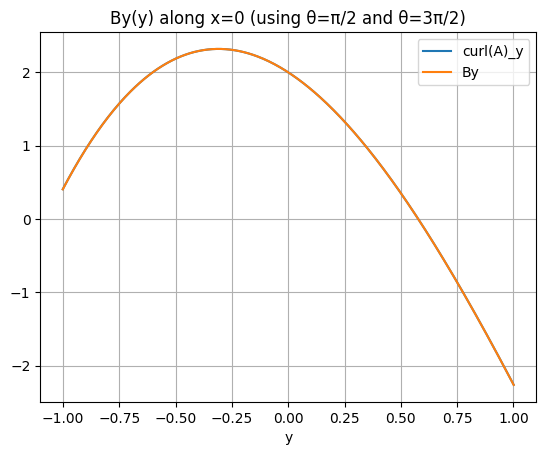

In [79]:

islice = 20   # choose an s index

# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
curly_pos = curl_y[:, itheta_pos, islice]
By_pos= By_ana[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
curly_neg = curl_y[:, itheta_neg, islice]
By_neg= By_ana[:, itheta_neg, islice]
# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
curly_all = np.concatenate([curly_neg, curly_pos])
By_all = np.concatenate([By_neg, By_pos])
order = np.argsort(y_all)
y_all = y_all[order]
curly_all = curly_all[order]
By_all =By_all[order]

plt.plot(y_all, curly_all, label='curl(A)_y')
plt.plot(y_all, By_all, label='By')
plt.xlabel("y")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")

plt.legend()
plt.grid(True)


HA on B

0.28205128205128194
1.7975016436554898


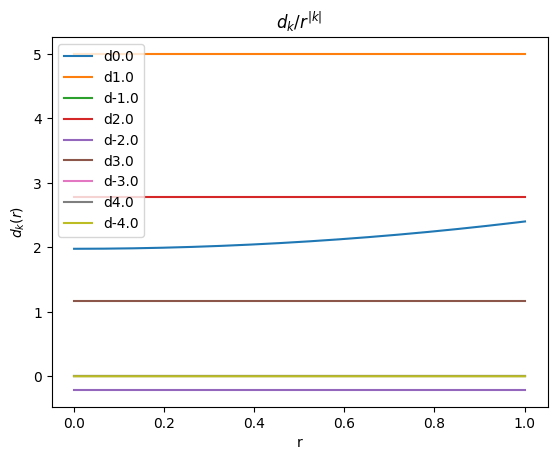

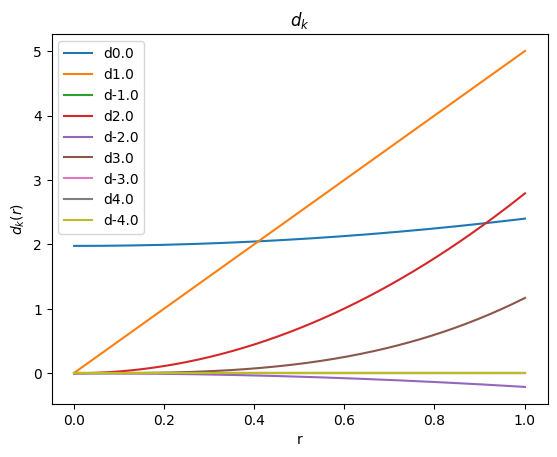

In [80]:
def rt2xy(r,theta):
    return r*np.cos(theta), r*np.sin(theta) #cartesian positions of points on which i have the field B_func 
sindex=25
s_fixed=ss[sindex]
print(s_fixed)
print(2-s_fixed+s_fixed**2)
nk=4 #maximum abs of k

def ByiBx(x, y):#analytical definition of By + i*Bx 
    return By_func(x, y,s_fixed) + 1j * Bx_func(x, y,s_fixed)
rr=np.linspace(rmin,rmax,nr)
# ByiBx=ByiBxfunc(x,y)
# theta=np.arange(ntheta)/ntheta*2*np.pi
# for r in range(rr):
#   x,y=rt2xy(r,theta)


def dkharmonics(ByiBx=ByiBx, rr=rr,nk=nk,ntheta=102): 
  '''
  returns dk as function of r 
  ''' 
  out=np.empty((len(rr),2*nk+1),dtype=complex) #prepare to store dk's as functions of r0 
  theta=np.arange(ntheta)/ntheta*2*np.pi
  for ir,r in enumerate(rr):
    x,y=rt2xy(r,theta)
    b=ByiBx(x,y)
    d=np.fft.fft(b)/ntheta #discrete fourier coefficients: dk at this r0
    out[ir,0]=d[0]#k=0
    out[ir,1::2]=d[1:nk+1] #first "fourier frequencies" are for positive k, stored in odd indexes
    out[ir,2::2]=d[ntheta:ntheta-nk-1:-1]#the last ones are for negative frequencies (take them in reverse order), stored in even indexes
  return out

dkofr=dkharmonics(rr=rr)
#plot dk(r)/r^|k|
for ki in range(2*nk+1): #plot dk(r)
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki]/rarr[:,0,sindex]**((ki+1)/2), label='d'+str((ki+1)/2))
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki]/rarr[:,0,sindex]**((ki)/2), label='d'+str(-ki/2))
plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.title('$d_k/r^{|k|}$')
plt.show()
#plot dk(r)
for ki in range(2*nk+1): #plot dk(r)
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki], label='d'+str((ki+1)/2))
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki], label='d'+str(-ki/2))
plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.title("$d_k$")
plt.show()



In [81]:

def dklfit(dkofrarray,rr,nk, nl):
  '''
  takes the result from dkharmonics and fits d_k/r^|k| for different k values as a funtion of r^2l, 
  the coefficients of the fit are the values d_kl 
  parameters:
  rr=array of r values
  nk= max of |k| (not the number of different k values)
  nl= number of l values
  returns: matrix dkl
  '''
  polynomial=np.zeros((len(rr), 2*nk+1),dtype=complex)#to store d_k/r^|k|
  ka=np.linspace(-nk,nk,2*nk+1)
  for ir,r in enumerate(rr):
     polynomial[ir,0]=dkofrarray[ir,0]#for k=0 it would be divided by r0^0=1
     polynomial[ir,1::2]=dkofrarray[ir,1::2]/r**ka[nk+1 : 2*nk+1] #for positive k, odd indexes
     polynomial[ir,2::2]=dkofrarray[ir,2::2]/r**-ka[0: nk] #for negative k
  dkl=np.zeros((2*nk+1, nl), dtype=complex)#different k along rows, different l along columns
  dkl[0,:]=np.polyfit(rr**2,polynomial[:,0],deg=nl-1)[::-1] #k=0, fit r^2 since the exponent is 2l
  dkl[1::2,:]=np.polyfit(rr**2, polynomial[:,1::2], deg=nl-1)[::-1,].T #positive k
  dkl[2::2,:]=np.polyfit(rr**2, polynomial[:,2::2], deg=nl-1)[::-1,].T #negative k
  return dkl 
#alternative version
def dklfitraw(dkofrarray, rr, nk, nl):
    '''
    takes the result from dkharmonics and fits d_k/r^|k| for different k values as a function of r^2l,
    the coefficients of the fit are the values d_kl
    parameters:
      rr    = array of r values
      nk    = max of |k| (not the number of different k values)
      nl    = number of l values
    returns: matrix dkl
    '''
    polynomial = np.zeros((len(rr), 2*nk+1), dtype=complex)
    ka = np.linspace(-nk, nk, 2*nk+1)

    for ir, r in enumerate(rr):
        polynomial[ir, 0]    = dkofrarray[ir, 0]
        polynomial[ir, 1::2] = dkofrarray[ir, 1::2] / r**ka[nk+1 : 2*nk+1]
        polynomial[ir, 2::2] = dkofrarray[ir, 2::2] / r**-ka[0: nk]

    # Build Vandermonde matrix for r^2, degrees 0..nl-1
    x = rr**2
    V = np.vander(x, nl, increasing=True)  # shape (len(rr), nl)

    # Fit all 2*nk+1 columns at once: coeffs shape is (nl, 2*nk+1)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    # dkl[k, l] layout: rows = k index, cols = l index
    dkl = coeffs.T  # shape (2*nk+1, nl)

    return dkl


nl=nk//2+1
prdkl=dklfitraw(dkofr,rr=rr,nk=nk, nl=nl)
print("columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...")
np.set_printoptions(suppress=True,precision=3)
print(prdkl)

#now let's recover the a,b coefficients
def bnianHAopt(dkl, nl, nk):
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int16)

    # Build k index dict mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k gets even row

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j #initialize sum
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):#
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result

bnianLHA =bnianHAopt(prdkl, nl=nl, nk=nk)
print("coeffs with my function")
print("bn=", bnianLHA.real)
print("an=", bnianLHA.imag)

coeffbpmeth=bpmeth.harmonics(ByiBx=ByiBx, nk=nk, rmin=rmin, rmax=rmax,nr=nr,ntheta=102)

bpmeth.print_harmonics(coeffbpmeth)
bnianbp = bpmeth.calc_coeffs(coeffbpmeth)
print("with bpmeth")
print("bn:", bnianbp.real)
print("an:", bnianbp.imag)

columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...
[[  1.978+1.j      0.423+0.j      0.   -0.j   ]
 [  5.   +2.j      0.   +0.j     -0.   -0.j   ]
 [ -0.   +0.j      0.   -0.j     -0.   +0.j   ]
 [  2.788+1.5j     0.   +0.j     -0.   -0.j   ]
 [ -6.877+0.j     29.582-0.j    -26.029+0.j   ]
 [  1.167+0.667j  -0.   -0.j      0.   +0.j   ]
 [ -0.   -0.j      0.   +0.j     -0.   -0.j   ]
 [  0.   -0.j     -0.   +0.j      0.   -0.j   ]
 [ -0.   +0.j      0.   -0.j     -0.   +0.j   ]]
coeffs with my function
bn= [ 1.978  5.    -7.331  7.   ]
an= [1. 2. 3. 4.]
k  l=0                       l=1                       l=2                       
 0    1.9775620,   1.0000000    0.4230769,   0.0000000    0.0000000,   0.0000000
 1    5.0000000,   2.0000000    0.0000000,  -0.0000000    0.0000000,  -0.0000000
-1   -0.0000000,   2.0000000   -0.0000000,  -0.0000000   -0.0000000,  -0.0000000
 2    2.7884615,   1.5000000   -0.0000000,  -0.0000000   -0.0000000,  -0.0000000
-2   -0.2115385,   1.5000000   -0.0000000,

In [82]:
#timing
def mylocalharmonics():
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkharmonics(ByiBx=ByiBx,rr=rr,nk=nk,ntheta=102)
    dkl=dklfitraw(dk,rr,nk, nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn

def bpmethlocalharmonics():
    dkl=bpmeth.harmonics(ByiBx=ByiBx,nk=nk,rmin=rmin, rmax=rmax,nr=nr, ntheta=102)
    an=bpmeth.calc_coeffs(dkl).imag
    bn=bpmeth.calc_coeffs(dkl).real
    return an, bn
N=100
import timeit
mytime=timeit.timeit("mylocalharmonics()", globals=globals(), number=N)
bpmethtime=timeit.timeit("bpmethlocalharmonics()", globals=globals(), number=N)
print("my time=", mytime)
print("bpmeth time", bpmethtime)
print("relative improvement timed over", N,"repetitions: (bpmeth time - new code time)/bpmeth time =", (bpmethtime-mytime)/bpmethtime*100,"%")

my time= 4.606653412998639
bpmeth time 4.415265883000757
relative improvement timed over 100 repetitions: (bpmeth time - new code time)/bpmeth time = -4.33467734604036 %


In [83]:
#for specified fixed s:
def mylocharmats(ss,sindex,korder):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b at a specified longitudinal position s
    '''
    s_fixed=ss[sindex]
    def ByiBxsfixed(x, y,sfixed=s_fixed):#analytical definition of By + i*Bx at s=s_fixed
        return By_func(x, y, sfixed) + 1j * Bx_func(x, y, sfixed)
    #ByiBxfixs=ByiBxsfixed(x, y,sfixed=s_fixed) #analytical definition of By + i*Bx at s=s_fixed
    dk=dkharmonics(ByiBx=ByiBxsfixed, rr=rr,nk=korder,ntheta=102)
    dkl=dklfit(dk,rr,nk, nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
anats, bnats =mylocharmats(ss=ss, sindex=25, korder=nk)
print("an(s=",ss[sindex],")=", anats)
print("bn(s=",ss[sindex],")=", bnats)

an(s= 0.28205128205128194 )= [1. 2. 3. 4.]
bn(s= 0.28205128205128194 )= [ 1.978  5.    -7.331  7.   ]


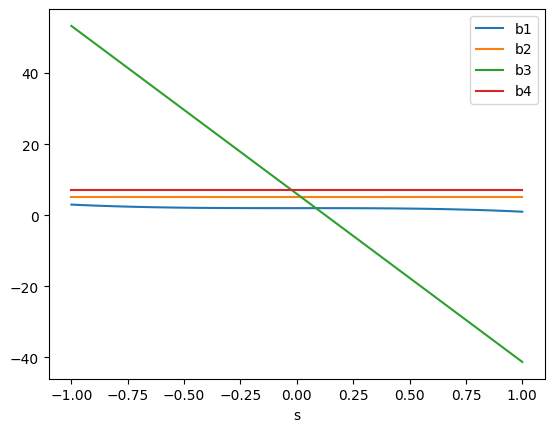

In [84]:
#HA as a function of s:
def HAofs(ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), 4))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = mylocharmats(ss,sindex=i,korder=korder)
    
    return svals, bofs
sss, bofs = HAofs(ss=ss,korder=4)
for j in range(bofs.shape[1]):
    plt.plot(sss, bofs[:,j], label='b'+str(j+1))
plt.legend()
plt.xlabel('s')
plt.show()
         

Now working on a grid for curl(A)

/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


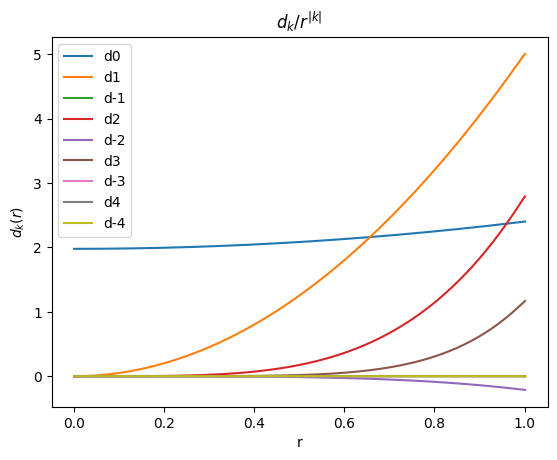

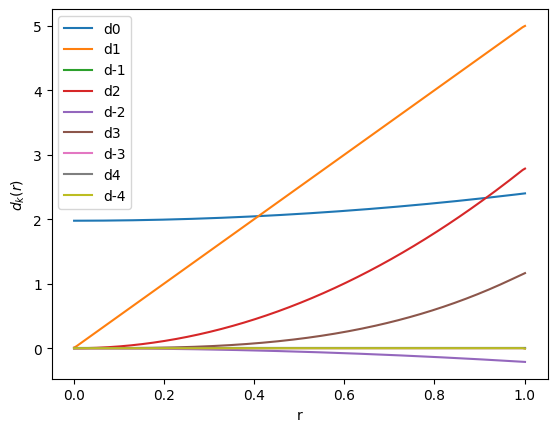

columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...
[[ 1.977+1.j     0.423-0.j    -0.   -0.j   ]
 [ 4.997+1.999j  0.007+0.003j -0.006-0.002j]
 [-0.   -0.j     0.   -0.j    -0.   +0.j   ]
 [ 2.785+1.498j  0.008+0.004j -0.007-0.004j]
 [-0.211-0.j    -0.001+0.j     0.   -0.j   ]
 [ 1.165+0.665j  0.005+0.003j -0.004-0.002j]
 [ 0.001-0.001j  0.002-0.j    -0.003+0.001j]
 [ 0.001-0.j    -0.001+0.j     0.001-0.j   ]
 [ 0.002-0.001j  0.001+0.j    -0.003+0.001j]]
a_n from curl  [1.    1.999 2.996 4.006]
b_n from curl  [1.977 4.997 5.994 7.042]
original a_n= [1, 2, 3, 4]
original b_n= ['2-s**3', 5, 6, 7]


In [ ]:
def dkongrid(Byibx_rts, rr, nk, s_index, ntheta=102):
    """
    Takes a precomputed field array and computes d_k as a function of r 
    
    Parameters
    ----------
    Byibx_rts : complex array, shape (nr, ntheta, ns)
        (By + i*Bx) already evaluated on the (r, theta, s) grid.
        Theta samples must be uniform in [0, 2*pi).
    rr     : array of r values, shape (nr,)
    nk     : max |k|
    s_index: index along the s-axis to use

    Returns
    -------
    out : complex array, shape (nr, 2*nk+1)  — same as dkharmonics
    """
    ntheta = Byibx_rts.shape[1]

    b = Byibx_rts[:, :, s_index]        # (nr, ntheta)
    d = np.fft.fft(b, axis=1) / ntheta       # FFT along theta axis

    out = np.empty((len(rr), 2*nk+1), dtype=complex)
    out[:, 0]    = d[:, 0]
    out[:, 1::2] = d[:, 1 : nk+1]
    out[:, 2::2] = d[:, ntheta : ntheta-nk-1 : -1]

    return out
def dklfitrawcut(dkofrarray, rr, nk, nl, rmin_fit=None):
    '''
    rmin_fit: minimum r to include in the fit (to avoid blow-up of dk/r^|k| at small r).
              Defaults to rr.max() * 0.6 if not given.
    '''
    if rmin_fit is None:
        rmin_fit = rr.max() * 0.6

    mask = rr >= rmin_fit
    rr_fit = rr[mask]
    dkofr_fit = dkofrarray[mask, :]

    polynomial = np.zeros((len(rr_fit), 2*nk+1), dtype=complex)
    kpos = np.arange(1, nk+1)   # [1, 2, ..., nk]

    for ir, r in enumerate(rr_fit):
        polynomial[ir, 0]    = dkofr_fit[ir, 0]
        polynomial[ir, 1::2] = dkofr_fit[ir, 1::2] / r**kpos   # positive k
        polynomial[ir, 2::2] = dkofr_fit[ir, 2::2] / r**kpos   # negative k, same |k|

    x = rr_fit**2
    V = np.vander(x, nl, increasing=True)
    coeffs, _, _, _ = np.linalg.lstsq(V, polynomial, rcond=None)

    return coeffs.T   # shape (2*nk+1, nl)
def LHongrid(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitrawcut(dk,rr,nk, nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn
curlyix=curl_y+1j*curl_x
#origByiBx=By_ana+1j*Bx_ana #to check from the original field
dkgridout=dkongrid(Byibx_rts=curlyix, rr=rr, nk=nk,s_index=25, ntheta=102)
#plot dk(r)/r^|k|
for ki in range(2*nk+1): 
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki]/rarr[:,0,sindex]**(-(ki+1)/2), label='d'+str((ki+1)//2))#for some reason i have to put a - in the exponent
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki]/rarr[:,0,sindex]**(-(ki)/2), label='d'+str(-ki//2))
plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.title('$d_k/r^{|k|}$')
plt.show()
#plot d_k(r)
for ki in range(2*nk+1): 
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki], label='d'+str((ki+1)//2))
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkgridout[:,ki], label='d'+str(-ki//2))
plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.show()

nl=nk//2+1
griddkl=dklfitrawcut(dkofrarray=dkgridout ,rr=rr,nk=nk, nl=nl)
print("columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...")
np.set_printoptions(suppress=True,precision=3)
print(griddkl)

acurl, bcurl = LHongrid(ByiBxongrid=curlyix, s_index=25, nk=nk)
print("a_n from curl ", acurl)
print("b_n from curl ", bcurl)
print("original a_n=", a_coeffs)
print("original b_n=", b_coeffs)


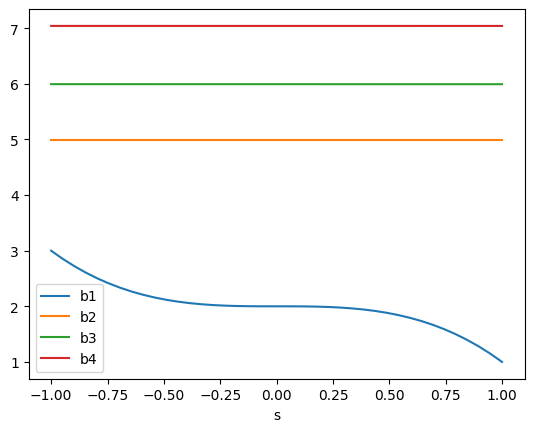

In [86]:
#HA as a function of s:
def LH_s_grid(fieldyix, ss,korder):
    svals = np.unique(ss) 
    bofs = np.zeros((len(svals), korder))

    #coeffsstd = np.zeros((len(svals), order))
    for i in range(len(svals)):
        _, bofs[i] = LHongrid(ByiBxongrid=fieldyix ,s_index=i, nk=korder)
    
    return svals, bofs
sss, bofs = LH_s_grid(fieldyix=curlyix,ss=ss, korder=4)
for j in range(bofs.shape[1]):
    plt.plot(sss, bofs[:,j], label='b'+str(j+1))
plt.legend()
plt.xlabel('s')
plt.show()

bpmeth at fixed s

In [87]:
datafieldmap = np.column_stack([
    xarr.ravel(),
    yarr.ravel(),
    sarr.ravel(),
    curl_x.ravel(),
    curl_y.ravel(),
    curl_s.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)
s_fixed = ss[25]
bnianfromcurl=curlfieldmap.harmonic_analysis_at_s(spos=s_fixed, order=4, rmin=rmin, rmax=rmax, nr=nr, radius=0.01 )

bn=bnianfromcurl.real[:len(b_coeffs)]
an=bnianfromcurl.imag[:len(a_coeffs)]

print("recovered bn: ",bn )
print("Original bn: ", b_coeffs)
print("recovered an: ", an )
print("Original an: ", a_coeffs)

recovered bn:  [     1.967      4.297      3.568 176640.874]
Original bn:  ['2-s**3', 5, 6, 7]
recovered an:  [     0.996      1.738     41.33  131383.049]
Original an:  [1, 2, 3, 4]


In [88]:
#When there is no s dependence in the original coefficients i can use fft
bnianfft=curlfieldmap.fft_at_s(spos=s_fixed, r=0.22, radius=0.006)
bnfft=bnianfft.real[:len(b_coeffs)]
print("bn recovered by Fourier transform: ",bnfft )
print("Original bn: ", b_coeffs)

bn recovered by Fourier transform:  [1.998 5.002 5.583 7.02 ]
Original bn:  ['2-s**3', 5, 6, 7]


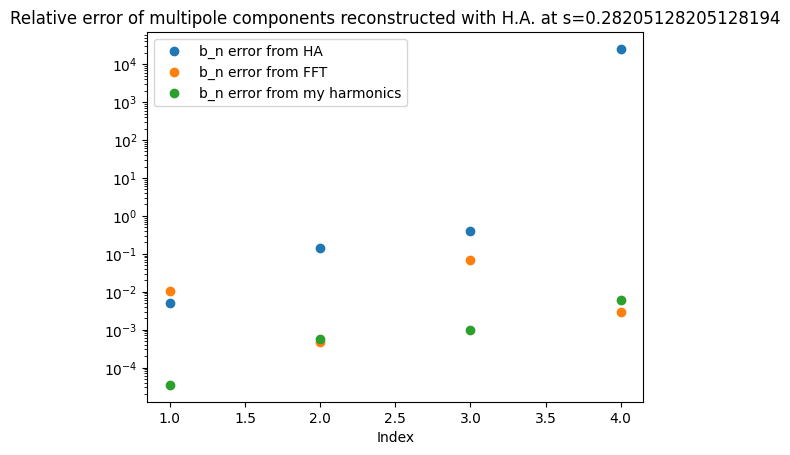

In [89]:
p=4#how many values to plot
#evaluate the symbolic expressions of the original coefficients to compare them with the recovered ones
b_eva = lambdify(s, b_coeffs, 'numpy')
a_eva = lambdify(s, a_coeffs, 'numpy')
#plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.yscale('log')
plt.xlabel('Index')

plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(s_fixed))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bn[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from HA')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bnfft[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from FFT')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_eva(s_fixed)[:p]-bcurl[:p])/b_eva(s_fixed)[:p], 'o', label='b_n error from my harmonics' )
plt.legend()
plt.show()

bpmeth local harmonic analysis as function of s

In [90]:
svalues, bpmbofs, bpmerrorbofs = curlfieldmap.s_harmonics(order=4,rmin=rr[24], rmax=rmax, nr=40-24, ntheta=102,radius=0.007 )

Text(0.5, 0, 's')

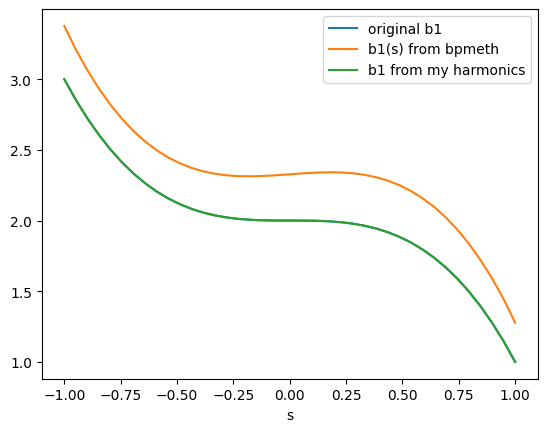

In [91]:
plt.plot(ss, b_eva(ss)[0], label="original b1")
plt.plot(ss, bpmbofs[:,0], label="b1(s) from bpmeth")
plt.plot(ss, bofs[:,0], label='b1 from my harmonics')
plt.legend()
plt.xlabel('s')